# Ultimate PIR Pipeline (V3.1): Bug Fixes & Optuna

This version fixes the `ValueError` in the Optuna tuning block and ensures all models (LightGBM, XGBoost, CatBoost) run smoothly with the hard location filter.


In [13]:
import polars as pl
import numpy as np
import pandas as pd
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier, Pool
from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD
import optuna
import matplotlib.pyplot as plt
import gc
import warnings
import re
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
pl.Config.set_tbl_rows(10)


polars.config.Config

In [14]:
def standardize_age(text):
    if text is None: return -1.0
    clean_text = str(text).strip().lower()
    if re.search(r'(\*|x\d|cm)', clean_text): return 0.5
    if re.search(r'\bb\d{2}\b', clean_text): return 25.0
    if 's17' in clean_text: return 1.0
    if '110' in clean_text: return 5.0
    if "không xác định" in clean_text or not clean_text: return -1.0
    
    diaper_map = {r'\bnb\b': 0, r'\bss\b': 0, r'\bsơ sinh\b': 0, r'\bs\b': 0.25, r'\bm\b': 0.6, r'\bl\b': 1.2, r'\bxl\b': 2.0, r'\bxxl\b': 3.5}
    for pattern, val in diaper_map.items():
        if re.search(pattern, clean_text): return float(val)
        
    range_match = re.search(r'(\d+\.?\d*)\s*-\s*(\d+\.?\d*)', clean_text)
    if range_match:
        avg = (float(range_match.group(1)) + float(range_match.group(2))) / 2
        if any(x in clean_text for x in ['m', 'tháng']): return round(avg / 12, 3)
        return avg
        
    m_match = re.search(r'(\d+\.?\d*)\s*(m|tháng)', clean_text)
    if m_match: return round(float(m_match.group(1)) / 12, 3)
    
    y_match = re.search(r'(\d+\.?\d*)\s*(y|t|tuổi)', clean_text)
    if y_match: return float(y_match.group(1))
    
    pure_num = re.search(r'^(\d+)$', clean_text)
    if pure_num:
        val = float(pure_num.group(1))
        if val > 6: return round(val/12, 3)
        else: return val
        
    return -1.0


In [15]:
def load_and_prep_data(transaction_path):
    return pl.scan_parquet(transaction_path).select([
        pl.col('customer_id').cast(pl.Int32),
        pl.col('item_id').cast(pl.Utf8),
        pl.col('updated_date').cast(pl.Datetime).alias('event_ts'),
        pl.col('quantity').cast(pl.Float32).fill_null(0.0),
        pl.col('event_type').cast(pl.Categorical),
        pl.col('price').cast(pl.Float32).fill_null(0.0),
        pl.col('location').cast(pl.Utf8)
    ]).filter(
        (pl.col('event_type') == 'purchased') | (pl.col('quantity') > 0)
    ).with_columns(
        pl.col('event_ts').dt.month().cast(pl.Int8).alias('month')
    ).collect()

T_PATH = '/kaggle/input/datasets/kinonquc/qkindataset2/transaction_full_2025.parquet'
I_PATH = '/kaggle/input/datasets/kinonquc/qkindataset2/items.parquet'
import os
if not os.path.exists(T_PATH):
    T_PATH, I_PATH = '../transaction_full_2025.parquet', '../items.parquet'

df_raw = load_and_prep_data(T_PATH)
items_df = pl.read_parquet(I_PATH).with_columns(pl.col('item_id').cast(pl.Utf8))

if 'size' in items_df.columns:
    items_df = items_df.with_columns(pl.col('size').map_elements(standardize_age, return_dtype=pl.Float32).alias('item_target_age'))
else:
    items_df = items_df.with_columns(pl.lit(-1.0).cast(pl.Float32).alias('item_target_age'))

item_locations = df_raw.group_by('item_id').agg(pl.col('location').unique().alias('item_hubs'))

df_train_base = df_raw.filter(pl.col('month') <= 10)
df_val_truth  = df_raw.filter(pl.col('month') == 11)
df_train_val_base = df_raw.filter(pl.col('month') <= 11)
df_test_truth = df_raw.filter(pl.col('month') == 12)


In [16]:
class Retriever:
    def __init__(self, history_df, item_locations):
        self.history_df = history_df
        self.item_locations = item_locations
        
        self.user_locs = history_df.group_by('customer_id').agg(
            pl.col('location').value_counts().struct.field('location').first().alias('primary_loc')
        ).to_dict(as_series=False)
        self.u2loc = dict(zip(self.user_locs['customer_id'], self.user_locs['primary_loc']))
        
        self.i2locs = {r[0]: set(r[1]) for r in item_locations.iter_rows()}
        
        q4_df = history_df.filter(pl.col('month') >= 9)
        self.q4_pop = q4_df.group_by('item_id').agg(pl.col('quantity').sum().alias('w')).sort('w', descending=True)['item_id'].head(200).to_list()
        
        interactions = history_df.group_by(['customer_id', 'item_id']).agg(pl.col('quantity').sum().alias('weight'))
        self.users = interactions['customer_id'].unique().to_list()
        self.items = interactions['item_id'].unique().to_list()
        self.user2idx = {u: i for i, u in enumerate(self.users)}
        self.item2idx = {i: idx for idx, i in enumerate(self.items)}
        
        row_idx = [self.user2idx[u] for u in interactions['customer_id']]
        col_idx = [self.item2idx[i] for i in interactions['item_id']]
        self.matrix = csr_matrix((interactions['weight'].to_numpy(), (row_idx, col_idx)), shape=(len(self.users), len(self.items)))
        
        svd = TruncatedSVD(n_components=64, random_state=42)
        self.user_factors = svd.fit_transform(self.matrix)
        self.item_factors = svd.components_.T
        
    def filter_loc(self, uid, candidates):
        u_loc = self.u2loc.get(uid, None)
        if not u_loc: return candidates
        return [c for c in candidates if u_loc in self.i2locs.get(c, set())]

    def get_candidates(self, target_users, top_k_svd=100, top_k_pop=50):
        all_cands = []
        rep_df = self.history_df.filter(pl.col('customer_id').is_in(target_users)).select(['customer_id', 'item_id']).unique()
        rep_dict = {row[0]: [] for row in rep_df.iter_rows()}
        for row in rep_df.iter_rows(): rep_dict[row[0]].append(row[1])
        
        for u in target_users:
            cands = set(rep_dict.get(u, []))
            if u in self.user2idx:
                u_idx = self.user2idx[u]
                scores = self.user_factors[u_idx] @ self.item_factors.T
                top_indices = np.argsort(-scores)[:top_k_svd*2]
                svd_raw = [self.items[i] for i in top_indices]
                cands.update(self.filter_loc(u, svd_raw)[:top_k_svd])
            cands.update(self.filter_loc(u, self.q4_pop)[:top_k_pop])
            for c in cands:
                all_cands.append({'customer_id': u, 'item_id': c})
        return pl.DataFrame(all_cands, schema={'customer_id': pl.Int32, 'item_id': pl.Utf8})


In [17]:
def build_features(history_df, candidates_df, items_df):
    user_feats = history_df.group_by('customer_id').agg([
        pl.col('item_id').n_unique().cast(pl.Float32).alias('user_unique_items'),
        pl.col('quantity').sum().cast(pl.Float32).alias('user_total_volume'),
        (pl.col('item_id').n_unique() / pl.len()).cast(pl.Float32).alias('user_exploration_ratio'),
        pl.col('price').mean().cast(pl.Float32).alias('user_avg_price')
    ])
    item_feats = history_df.group_by('item_id').agg([
        pl.col('quantity').sum().cast(pl.Float32).alias('item_global_vol'),
        pl.col('customer_id').n_unique().cast(pl.Float32).alias('item_unique_buyers')
    ])
    max_date = history_df['event_ts'].max()
    t1 = max_date - pl.duration(days=14)
    momentum_df = history_df.group_by('item_id').agg([
        pl.col('event_ts').filter(pl.col('event_ts') >= t1).len().alias('recent_14d_sales'),
        pl.col('event_ts').filter(pl.col('event_ts') < t1).len().alias('past_sales')
    ]).with_columns(
        (pl.col('recent_14d_sales') / (pl.col('past_sales') + 1.0)).cast(pl.Float32).alias('item_momentum_ratio')
    ).select(['item_id', 'item_momentum_ratio'])
    item_feats = item_feats.join(momentum_df, on='item_id', how='left').fill_null(0.0)
    inter_feats = history_df.group_by(['customer_id', 'item_id']).agg([
        pl.col('quantity').sum().cast(pl.Float32).alias('ui_buy_vol'),
        (max_date - pl.col('event_ts').max()).dt.total_days().cast(pl.Int16).alias('ui_days_since_last_buy')
    ])
    df_feat = candidates_df.join(user_feats, on='customer_id', how='left')
    df_feat = df_feat.join(item_feats, on='item_id', how='left')
    df_feat = df_feat.join(inter_feats, on=['customer_id', 'item_id'], how='left')
    df_feat = df_feat.join(items_df.select(['item_id', 'item_target_age', 'category_l1']), on='item_id', how='left')
    df_feat = df_feat.with_columns(pl.col('category_l1').fill_null('Unknown').cast(pl.Categorical))
    df_feat = df_feat.fill_null(0)
    return df_feat

def create_dataset(history_df, truth_df, items_df, item_locations, sample_users=None, n_negatives=30):
    target_users = truth_df['customer_id'].unique().to_list()
    if sample_users and sample_users < len(target_users):
        np.random.seed(42)
        target_users = list(np.random.choice(target_users, sample_users, replace=False))
        truth_df = truth_df.filter(pl.col('customer_id').is_in(target_users))
    retriever = Retriever(history_df, item_locations)
    candidates = retriever.get_candidates(target_users, top_k_svd=100, top_k_pop=50)
    truth_pairs = truth_df.select(['customer_id', 'item_id']).unique().with_columns(pl.lit(1).cast(pl.Int8).alias('target'))
    max_hits_possible = candidates.join(truth_pairs, on=['customer_id', 'item_id'], how='inner').height
    total_actual_hits = truth_pairs.height
    print(f"-> RETRIEVAL RECALL LIMIT: {max_hits_possible}/{total_actual_hits} ({(max_hits_possible/total_actual_hits)*100:.2f}%)")
    dataset = candidates.join(truth_pairs, on=['customer_id', 'item_id'], how='left').fill_null(0)
    if n_negatives:
        df_pos = dataset.filter(pl.col('target') == 1)
        df_neg = dataset.filter(pl.col('target') == 0)
        df_neg_sampled = df_neg.group_by('customer_id').map_groups(lambda df: df.sample(n=min(len(df), n_negatives), seed=42) if len(df) > 0 else df)
        dataset = pl.concat([df_pos, df_neg_sampled]).sample(fraction=1.0, seed=42, shuffle=True)
    return build_features(history_df, dataset, items_df)

print("=== BUILDING TRAINING DATA ===")
train_data = create_dataset(df_train_base, df_val_truth, items_df, item_locations, sample_users=50000, n_negatives=30)
print("\n=== BUILDING TEST DATA ===")
test_data = create_dataset(df_train_val_base, df_test_truth, items_df, item_locations, sample_users=20000, n_negatives=None)


=== BUILDING TRAINING DATA ===
-> RETRIEVAL RECALL LIMIT: 89791/213439 (42.07%)

=== BUILDING TEST DATA ===
-> RETRIEVAL RECALL LIMIT: 32471/78323 (41.46%)


In [18]:
feature_cols = [
    'user_unique_items', 'user_total_volume', 'user_exploration_ratio', 'user_avg_price',
    'item_global_vol', 'item_unique_buyers', 'item_momentum_ratio', 'item_target_age',
    'ui_buy_vol', 'ui_days_since_last_buy'
]
cat_cols = ['category_l1']
all_feats = feature_cols + cat_cols

X_train = train_data.select(all_feats).to_pandas()
y_train = train_data['target'].to_pandas()
X_train['category_l1'] = X_train['category_l1'].astype('category')

X_test = test_data.select(all_feats).to_pandas()
y_test = test_data['target'].to_pandas()
X_test['category_l1'] = X_test['category_l1'].astype('category')

def objective(trial):
    params = {
        'objective': 'binary',
        'metric': 'binary_logloss', # Fixed metric name
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'max_depth': trial.suggest_int('max_depth', 4, 10),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 50, 500)
    }
    trn_set = lgb.Dataset(X_train, label=y_train)
    val_set = lgb.Dataset(X_test, label=y_test, reference=trn_set)
    
    # Added valid_names to avoid empty evaluation list error
    model = lgb.train(
        params, 
        trn_set, 
        num_boost_round=100, 
        valid_sets=[val_set], 
        valid_names=['valid'],
        callbacks=[lgb.early_stopping(10), lgb.log_evaluation(0)]
    )
    return model.best_score['valid']['binary_logloss']

print("Running Optuna Tuning for LightGBM... (5 trials for speed)")
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=5)
best_lgb_params = study.best_params
best_lgb_params['objective'] = 'binary'
best_lgb_params['metric'] = 'binary_logloss'
print("Best Params:", best_lgb_params)


Running Optuna Tuning for LightGBM... (5 trials for speed)
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[32]	valid's binary_logloss: 0.0832923
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[60]	valid's binary_logloss: 0.0812909
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[25]	valid's binary_logloss: 0.0822182
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[7]	valid's binary_logloss: 0.0860946
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[10]	valid's binary_logloss: 0.0830196
Best Params: {'learning_rate': 0.01816285936660575, 'num_leaves': 33, 'max_depth': 4, 'min_data_in_leaf': 441, 'objective': 'binary', 'metric': 'binary_logloss'}


In [19]:
print("Training LightGBM with Best Params...")
lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_model = lgb.train(best_lgb_params, lgb_train, num_boost_round=300)

print("Training XGBoost...")
xgb_model = xgb.XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=6, enable_categorical=True, random_state=42)
xgb_model.fit(X_train, y_train)

print("Training CatBoost...")
cb_model = CatBoostClassifier(iterations=200, learning_rate=0.05, depth=6, cat_features=['category_l1'], verbose=0, random_seed=42)
cb_model.fit(X_train, y_train)


Training LightGBM with Best Params...
Training XGBoost...
Training CatBoost...


CatBoostClassifier(cat_features=['category_l1'], depth=6, iterations=200, learning_rate=0.05, random_seed=42, verbose=0)

<Figure size 1000x600 with 0 Axes>

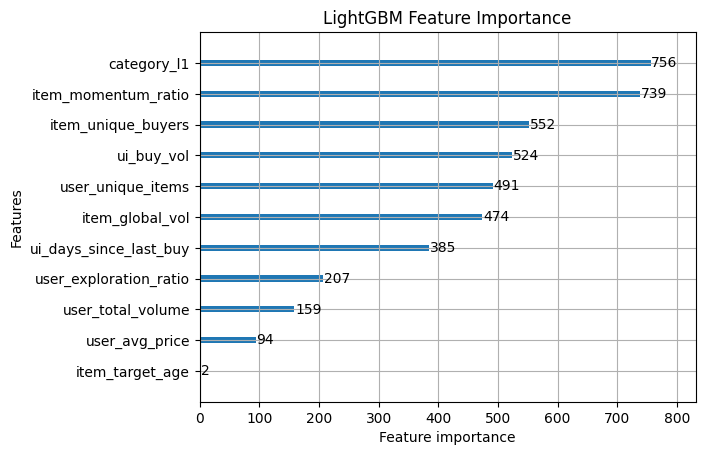

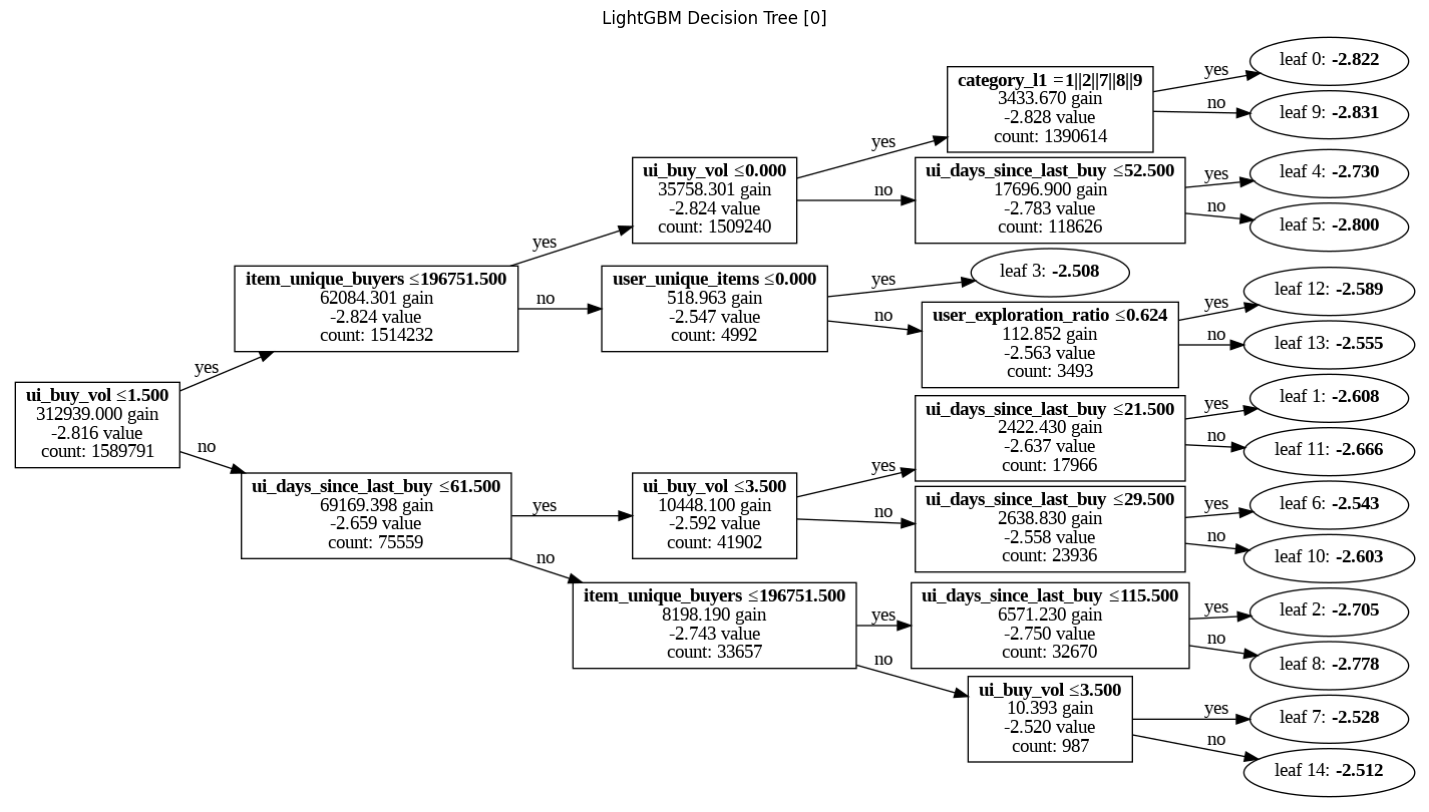

In [20]:
plt.figure(figsize=(10, 6))
lgb.plot_importance(lgb_model, max_num_features=15, title='LightGBM Feature Importance')
plt.show()

fig, ax = plt.subplots(figsize=(20, 10))
lgb.plot_tree(lgb_model, tree_index=0, ax=ax, show_info=['split_gain', 'internal_value', 'internal_count'])
plt.title('LightGBM Decision Tree [0]')
plt.show()


In [21]:
test_data = test_data.with_columns([
    pl.Series(name='pred_lgb', values=lgb_model.predict(X_test)),
    pl.Series(name='pred_xgb', values=xgb_model.predict_proba(X_test)[:, 1]),
    pl.Series(name='pred_cb', values=cb_model.predict_proba(X_test)[:, 1])
])

def evaluate_model(model_col):
    top10 = test_data.sort(['customer_id', model_col], descending=[False, True]).group_by('customer_id', maintain_order=True).head(10)
    truth_map = df_test_truth.filter(pl.col('customer_id').is_in(top10['customer_id'].unique().to_list())).group_by('customer_id').agg(pl.col('item_id'))
    truth_dict = {row[0]: set(row[1]) for row in truth_map.iter_rows()}
    pred_map = top10.group_by('customer_id').agg(pl.col('item_id'))
    pred_dict = {row[0]: list(row[1]) for row in pred_map.iter_rows()}
    
    total_hits, mrr_sum, p10_sum = 0, 0.0, 0.0
    n_users = len(truth_dict)
    if n_users == 0: return {}
    
    for uid, truth in truth_dict.items():
        preds = pred_dict.get(uid, [])
        hits = [p for p in preds if p in truth]
        total_hits += len(hits)
        p10_sum += len(hits) / 10.0 if len(preds) > 0 else 0.0
        for i, p in enumerate(preds):
            if p in truth:
                mrr_sum += 1.0 / (i + 1)
                break
    return {'Hits': total_hits, 'Precision@10': p10_sum / n_users, 'MRR': mrr_sum / n_users}

print("=== LightGBM Results ===")
for k, v in evaluate_model('pred_lgb').items(): print(f"{k}: {v:.4f}")
print("\n=== XGBoost Results ===")
for k, v in evaluate_model('pred_xgb').items(): print(f"{k}: {v:.4f}")
print("\n=== CatBoost Results ===")
for k, v in evaluate_model('pred_cb').items(): print(f"{k}: {v:.4f}")


=== LightGBM Results ===
Hits: 16506.0000
Precision@10: 0.0825
MRR: 0.2994

=== XGBoost Results ===
Hits: 13262.0000
Precision@10: 0.0663
MRR: 0.2383

=== CatBoost Results ===
Hits: 16499.0000
Precision@10: 0.0825
MRR: 0.3000
